# Validação 20 — Pesquisa adversarial com proveniência

## Goal

Validar uma camada adicional de segurança para a análise de alegações de saúde. Um agente **pesquisador** redige observações ligadas a trechos recuperados; um agente **crítico** procura erros e extrapolações; por fim, um **árbitro determinístico** verifica as citações e decide entre:

- `CORROBORATED`: compatível apenas com o conjunto recuperado, nunca “verdade comprovada”;
- `DISPUTED`: há conflito de evidências ou objeção crítica;
- `INSUFFICIENT`: faltam evidências ou a proveniência falhou.

Este notebook é um teste controlado de engenharia. Ele **não é validação clínica**, não mede acurácia médica e não substitui especialistas.

## Setup

Os dois agentes abaixo são simulados e determinísticos. Isso permite testar as barreiras de segurança sem depender de rede, chave de API ou variações de um modelo generativo. Os adaptadores para modelos reais serão uma etapa posterior e deverão manter o mesmo contrato estruturado.

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from fatofake import (
    AUTOMATED_REVIEW_DISCLAIMER,
    AdversarialCritique,
    AdversarialReviewService,
    ArticleQualityProfile,
    ArticleSynthesis,
    CitedObservation,
    CorpusSynthesis,
    CritiqueIssue,
    EvidenceAssessment,
    EvidenceDirection,
    EvidenceReport,
    EvidenceStatement,
    EvidenceStrength,
    IssueSeverity,
    QualityLevel,
    RelationLabel,
    RelationProbabilities,
    ReportConclusion,
    ReportSource,
    ResearchDraft,
    ReviewStatus,
)

CLAIM = "O consumo de café aumenta o risco de câncer de próstata."
print("Módulo carregado e alegação controlada definida.")

Módulo carregado e alegação controlada definida.


## Steps

### 1. Criar duas evidências independentes e um relatório-base

As evidências são sintéticas para que o resultado esperado seja conhecido. Cada observação deverá repetir exatamente o `statement_id`, PMID, URL, relação e trecho armazenados pelo pipeline.

In [2]:
def make_assessment(pmid, text):
    evidence = EvidenceStatement(
        statement_id=f"statement-{pmid}",
        text=text,
        extraction_score=0.90,
        matched_claim_terms=("coffee", "prostate"),
        hybrid_rank=1,
        sentence_index=1,
        chunk_id=f"chunk-{pmid}",
        pmid=pmid,
        pmcid=f"PMC{pmid}",
        doi=f"10.1000/{pmid}",
        section="Results",
        source_url=f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/",
    )
    return EvidenceAssessment(
        pair_id=f"pair-{pmid}",
        relation=RelationLabel.CONTRADICTS,
        model_relation=RelationLabel.CONTRADICTS,
        confidence=0.84,
        margin=0.76,
        probabilities=RelationProbabilities(0.08, 0.84, 0.08),
        rationale="Classificação controlada.",
        model_name="controlled-nli",
        claim=CLAIM,
        evidence=evidence,
    )


assessments = (
    make_assessment("1001", "The study found no increase in prostate cancer risk among coffee consumers."),
    make_assessment("1002", "Coffee intake was not associated with higher prostate cancer incidence."),
)


def make_report(conclusion=ReportConclusion.INCOMPATIBLE_WITH_EVIDENCE):
    direction = EvidenceDirection.MIXED if conclusion is ReportConclusion.CONFLICTING_EVIDENCE else EvidenceDirection.CONTRADICTS
    strength = EvidenceStrength.INSUFFICIENT if conclusion is ReportConclusion.INSUFFICIENT_EVIDENCE else EvidenceStrength.MODERATE
    articles = []
    for item in assessments:
        quality = ArticleQualityProfile(
            pmid=item.evidence.pmid,
            level=QualityLevel.MODERATE,
            study_design="Exemplo controlado",
            rationale="Perfil metodológico controlado.",
            source_url=item.evidence.source_url,
        )
        articles.append(ArticleSynthesis(
            pmid=item.evidence.pmid,
            direction=direction,
            support_probability=0.08,
            contradiction_probability=0.84,
            neutral_probability=0.08,
            assessment_count=1,
            relation_counts=((RelationLabel.CONTRADICTS.value, 1),),
            has_internal_conflict=False,
            uncertain_count=0,
            quality=quality,
        ))
    synthesis = CorpusSynthesis(
        direction=direction,
        strength=strength,
        support_probability=0.08,
        contradiction_probability=0.84,
        neutral_probability=0.08,
        article_count=2,
        has_conflict=conclusion is ReportConclusion.CONFLICTING_EVIDENCE,
        rationale="Síntese controlada.",
        articles=tuple(articles),
    )
    return EvidenceReport(
        claim=CLAIM,
        conclusion=conclusion,
        headline="Relatório controlado",
        summary="Resumo controlado.",
        synthesis=synthesis,
        methodology=(),
        limitations=(),
        sources=tuple(ReportSource(
            label=f"PMID {item.evidence.pmid}",
            url=item.evidence.source_url,
            pmid=item.evidence.pmid,
        ) for item in assessments),
    )


base_report = make_report()
print(f"Evidências: {len(assessments)} artigos | conclusão-base: {base_report.conclusion.value}")

Evidências: 2 artigos | conclusão-base: INCOMPATIBLE_WITH_EVIDENCE


### 2. Simular pesquisador e crítico com saídas estruturadas

O árbitro não confia no texto dos agentes para decidir. Ele confronta cada citação com o catálogo de evidências e preserva a conclusão conservadora do relatório-base.

In [3]:
def observation(item, index):
    return CitedObservation(
        observation_id=f"obs-{index}",
        statement_id=item.evidence.statement_id,
        pmid=item.evidence.pmid,
        quote=item.evidence.text,
        relation=item.relation,
        source_url=item.evidence.source_url,
        interpretation="O trecho contradiz a alegação dentro do corpus recuperado.",
    )


def grounded_draft(items=assessments):
    return ResearchDraft(
        summary="As evidências recuperadas não indicam aumento do risco.",
        observations=tuple(observation(item, index) for index, item in enumerate(items, 1)),
        search_queries=("coffee prostate cancer risk",),
        limitations=("Cenário sintético para teste de software.",),
        model_name="controlled-researcher",
        prompt_version="research-v1",
    )


class ControlledResearcher:
    def __init__(self, draft):
        self.draft = draft

    def research(self, claim, assessments, report):
        return self.draft


class ControlledCritic:
    def __init__(self, issues=()):
        self.issues = tuple(issues)

    def critique(self, claim, assessments, report, draft):
        return AdversarialCritique(
            summary="Crítica independente controlada.",
            issues=self.issues,
            model_name="controlled-critic",
            prompt_version="critic-v1",
        )


def run_review(draft, report=base_report, issues=()):
    service = AdversarialReviewService(
        ControlledResearcher(draft),
        ControlledCritic(issues),
    )
    return service.review(CLAIM, assessments, report)

### 3. Executar cenários de segurança

O caso normal pode ser corroborado **somente em relação ao corpus recuperado**. Todos os casos inseguros devem ser recusados ou contestados.

In [4]:
valid = grounded_draft()
hallucinated = replace(
    valid,
    observations=(
        replace(valid.observations[0], statement_id="statement-invented"),
        replace(valid.observations[1], quote="Trecho modificado pelo agente."),
    ),
)
population_issue = CritiqueIssue(
    code="POPULATION_MISMATCH",
    severity=IssueSeverity.CRITICAL,
    message="A população analisada não corresponde à população da alegação.",
    observation_id="obs-1",
)

scenarios = [
    ("Citações válidas", ReviewStatus.CORROBORATED, valid, base_report, ()),
    ("Citação inventada/modificada", ReviewStatus.INSUFFICIENT, hallucinated, base_report, ()),
    ("Divergência crítica", ReviewStatus.DISPUTED, valid, base_report, (population_issue,)),
    ("Base insuficiente com consenso", ReviewStatus.INSUFFICIENT, valid, make_report(ReportConclusion.INSUFFICIENT_EVIDENCE), ()),
    ("Apenas um artigo citado", ReviewStatus.INSUFFICIENT, grounded_draft(assessments[:1]), base_report, ()),
]

results = []
for name, expected, draft, report, issues in scenarios:
    result = run_review(draft, report, issues)
    results.append({
        "cenário": name,
        "esperado": expected.value,
        "obtido": result.status.value,
        "passou": result.status is expected,
        "problemas": ", ".join(p.code for p in result.provenance_problems) or "—",
        "resultado": result,
    })

rows = "".join(
    f"<tr><td>{r['cenário']}</td><td>{r['esperado']}</td><td>{r['obtido']}</td>"
    f"<td>{'✅' if r['passou'] else '❌'}</td><td>{r['problemas']}</td></tr>"
    for r in results
)
display(HTML(
    "<table><thead><tr><th>Cenário</th><th>Esperado</th><th>Obtido</th><th>Teste</th><th>Problemas de proveniência</th></tr></thead>"
    f"<tbody>{rows}</tbody></table>"
))

Cenário,Esperado,Obtido,Teste,Problemas de proveniência
Citações válidas,CORROBORATED,CORROBORATED,✅,—
Citação inventada/modificada,INSUFFICIENT,INSUFFICIENT,✅,"UNKNOWN_STATEMENT, QUOTE_MISMATCH"
Divergência crítica,DISPUTED,DISPUTED,✅,—
Base insuficiente com consenso,INSUFFICIENT,INSUFFICIENT,✅,—
Apenas um artigo citado,INSUFFICIENT,INSUFFICIENT,✅,—


### 4. Medir abstenção e falsa promoção

“Falsa promoção” significa transformar um caso que deveria ser `INSUFFICIENT` ou `DISPUTED` em `CORROBORATED`. É a falha de segurança prioritária nesta validação.

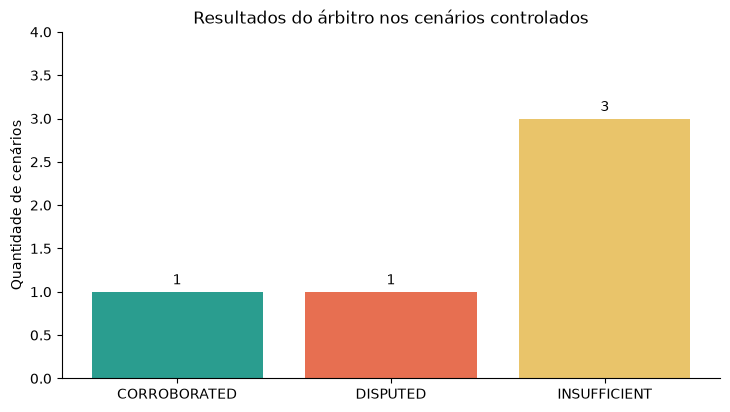

Casos aprovados: 5/5
Falsas promoções: 0


In [5]:
passed = sum(item["passou"] for item in results)
false_promotions = sum(
    item["esperado"] != ReviewStatus.CORROBORATED.value
    and item["obtido"] == ReviewStatus.CORROBORATED.value
    for item in results
)
status_counts = {
    status.value: sum(item["obtido"] == status.value for item in results)
    for status in ReviewStatus
}

fig, ax = plt.subplots(figsize=(8.5, 4.5))
labels = list(status_counts)
values = [status_counts[label] for label in labels]
colors = ["#2a9d8f", "#e76f51", "#e9c46a"]
bars = ax.bar(labels, values, color=colors)
ax.bar_label(bars, padding=3)
ax.set_title("Resultados do árbitro nos cenários controlados")
ax.set_ylabel("Quantidade de cenários")
ax.set_ylim(0, max(values) + 1)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

print(f"Casos aprovados: {passed}/{len(results)}")
print(f"Falsas promoções: {false_promotions}")

## Checks

As asserções abaixo fazem o notebook falhar se uma alteração futura aceitar citação inventada, ignorar objeção crítica ou elevar evidência insuficiente por simples concordância entre agentes.

In [6]:
assert passed == len(results)
assert false_promotions == 0
assert results[1]["resultado"].provenance_problems
assert results[2]["resultado"].status is ReviewStatus.DISPUTED
assert results[3]["resultado"].status is ReviewStatus.INSUFFICIENT
assert "não determina" in AUTOMATED_REVIEW_DISCLAIMER

display(Markdown("### Aviso exibido ao usuário\n\n> " + AUTOMATED_REVIEW_DISCLAIMER))
print("Todas as barreiras controladas foram preservadas.")

### Aviso exibido ao usuário

> Esta é uma análise automatizada e experimental da literatura recuperada. Ela pode omitir estudos ou interpretar evidências incorretamente, não determina se uma alegação é verdadeira e não substitui avaliação profissional ou revisão sistemática. Consulte os trechos, fontes e limitações apresentados antes de formar uma conclusão.

Todas as barreiras controladas foram preservadas.


## Conclusão e limitações

A camada adversarial melhora a auditabilidade: o pesquisador precisa apontar trechos existentes, o crítico pode bloquear extrapolações e o árbitro impede que consenso entre modelos substitua força de evidência. Nos cinco cenários controlados, o comportamento esperado foi preservado e não houve falsa promoção.

Este resultado comprova apenas as **regras de software**. Os agentes são simulados; modelos reais podem compartilhar os mesmos vieses, omitir estudos ou interpretar mal resultados. A avaliação futura deve usar um conjunto **prata** baseado em revisões, diretrizes e casos de retratação, deixando explícito que não é um conjunto ouro clínico.

## Next Steps

Implementar adaptadores reais para pesquisador e crítico, mantendo saídas estruturadas e modelos ou prompts versionados. Depois, montar o conjunto prata e medir recuperação, correção das citações, taxa de abstenção e falsa segurança antes de expor essa camada na API.